In [1]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np
from hmmlearn.hmm import GaussianHMM
import hdbscan
import plotly.graph_objects as go



In [2]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [3]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-05 00:00:00+05:30,0.000000,0.094707,0.000000,0.086095,0.000000,0.052627,0.000000,0.034146,0.049268,0.079448,...,0.022316,0.000000,0.007209,0.042414,0.000000,0.000000,0.097714,0.014177,0.101710,0.000000
2008-06-06 00:00:00+05:30,0.000000,0.096463,0.000000,0.093592,0.000000,0.055477,0.000000,0.038427,0.048164,0.072977,...,0.026902,0.000000,0.004996,0.039518,0.000000,0.000000,0.092051,0.016242,0.101359,0.000000
2008-06-09 00:00:00+05:30,0.000000,0.097814,0.000000,0.100934,0.000000,0.060673,0.000000,0.042575,0.046727,0.065568,...,0.032963,0.000000,0.002542,0.034720,0.000000,0.000000,0.085397,0.017465,0.100786,0.000000
2008-06-10 00:00:00+05:30,0.000000,0.099855,0.000000,0.104100,0.000000,0.071059,0.000000,0.047309,0.046517,0.058178,...,0.038096,0.000000,0.001713,0.030261,0.000000,0.000000,0.080686,0.019027,0.099659,0.000000
2008-06-11 00:00:00+05:30,0.000000,0.100483,0.000000,0.105155,0.000000,0.084748,0.000000,0.052642,0.045687,0.050810,...,0.045469,0.000058,0.000870,0.026759,0.000000,0.000000,0.075993,0.020184,0.097661,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12 00:00:00+05:30,0.150253,0.171876,0.110617,0.016477,0.000274,0.000000,0.104171,0.077467,0.020435,0.000000,...,0.041521,0.073654,0.000000,0.000000,0.025725,0.050502,0.000000,0.019644,0.066028,0.036041
2025-09-15 00:00:00+05:30,0.140572,0.171512,0.102708,0.012511,0.000518,0.000000,0.113352,0.073049,0.019066,0.000000,...,0.039853,0.072866,0.000000,0.000000,0.025318,0.053611,0.000000,0.021749,0.061992,0.034028
2025-09-16 00:00:00+05:30,0.128521,0.175892,0.093519,0.008835,0.000000,0.000000,0.121123,0.067323,0.016315,0.000000,...,0.037340,0.075898,0.000000,0.000000,0.024032,0.058974,0.000000,0.025540,0.057928,0.034247


In [4]:
30*0.6

18.0

In [5]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=6,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon = 0.1,   
    allow_single_cluster=False,
    prediction_data=True
)
labels = clusterer.fit_predict(embeddings)

In [6]:
df["HDBSCAN_Labels"] = labels

In [7]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head()

HDBSCAN_Labels
-1     0.165802
 41    0.054953
 21    0.053066
 27    0.032075
 32    0.032075
Name: proportion, dtype: float64

In [8]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head().to_clipboard()

In [9]:
df["HDBSCAN_Labels"].nunique() #51

51

In [10]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HDBSCAN_Labels"].dropna().unique()):
    mask = df["HDBSCAN_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

In [11]:
# plt.figure(figsize=(25,6))

# for c in df['HDBSCAN_Labels'].dropna().unique():
#     mask = df['HDBSCAN_Labels'] == c
#     plt.scatter(df.index[mask], df['Close'][mask], label=f"Regime {c}", s=10)
# plt.plot(df.index, df['Close'], color='black', linewidth=0.5, alpha=0.6)
# plt.title("Nifty 50 Regimes (Clustering)")
# plt.legend()
# plt.show()

In [12]:
hdb_labels = df["HDBSCAN_Labels"].values

In [13]:
from sklearn.metrics import pairwise_distances_argmin

# Ensure we operate on numpy arrays (pairwise_distances_argmin expects array-like)
X = embeddings.to_numpy() if hasattr(embeddings, "to_numpy") else np.asarray(embeddings)
labels = np.asarray(hdb_labels).copy()

# centroids from non-noise clusters
clusters = np.unique(labels[labels >= 0])

# If everything is noise (or there are no points), we can't reassign
if clusters.size == 0:
    print("No non-noise clusters found; leaving labels unchanged.")
else:
    centroids = np.vstack([X[labels == k].mean(axis=0) for k in clusters])

    # reassign noise (if any) to nearest centroid
    noise_idx = np.where(labels == -1)[0]
    if noise_idx.size == 0:
        print("No noise points to reassign.")
    else:
        nearest = pairwise_distances_argmin(X[noise_idx], centroids)
        labels[noise_idx] = clusters[nearest]

In [14]:
np.mean(labels == -1)

0.0

In [15]:
len(centroids)

50

In [16]:
from sklearn.cluster import AgglomerativeClustering

K0 = 15  # start here

agg = AgglomerativeClustering(
    n_clusters=K0,
    linkage="ward"
)

proto_labels = agg.fit_predict(centroids)

In [17]:
proto_labels

array([ 9,  3,  4,  8,  8,  2,  1,  4,  4,  1, 14,  6,  4,  3,  8,  9,  9,
       12,  5,  0, 13,  5,  5,  0,  0,  0,  2,  7,  6,  6,  1, 12,  2,  3,
        1,  4,  1, 11, 10, 11,  0,  0,  1, 11, 10,  7,  7,  0,  1,  0])

In [18]:
proto_state = np.zeros_like(labels)
cluster_ids = np.unique(labels)

for cid, p in zip(cluster_ids, proto_labels):
    proto_state[labels == cid] = p

In [19]:
np.unique(proto_state)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [20]:
def init_from_micro_regimes(X, labels, min_points=20):
    states = np.unique(labels)
    means, covs = [], []

    for k in states:
        pts = X[labels == k]
        if len(pts) < min_points:
            continue
        means.append(pts.mean(axis=0))
        covs.append(
            np.cov(pts.T) + 1e-6 * np.eye(X.shape[1])
        )

    return np.array(means), np.array(covs)


def full_to_diag_cov(covs):
    """
    covs: (K, D, D)
    returns: (K, D)
    """
    return np.array([
        np.diag(cov) for cov in covs
    ])


def init_from_proto_states_diag(X, proto_state, min_points=50):
    states = np.unique(proto_state)
    means, diag_covs = [], []

    for k in states:
        pts = X[proto_state == k]
        if len(pts) < min_points:
            continue

        mu = pts.mean(axis=0)
        cov = np.cov(pts.T)

        # strong regularization for stability
        cov += 1e-3 * np.eye(X.shape[1])

        means.append(mu)
        diag_covs.append(np.diag(cov))

    return np.array(means), np.array(diag_covs)

In [21]:
init_means, init_covs = init_from_proto_states_diag(
    embeddings, proto_state
)

K = len(init_means)
print("HMM init states:", K)

HMM init states: 15


In [22]:
from hmmlearn.hmm import GaussianHMM

def sticky_transition(K, kappa=70, base=1.0):
    A = np.full((K, K), base)
    np.fill_diagonal(A, base + kappa)
    return A / A.sum(axis=1, keepdims=True)


model = GaussianHMM(
    n_components=K,
    covariance_type="diag",   
    n_iter=1500,
    tol=1e-3,
    init_params=""
)

model.startprob_ = np.ones(K) / K
model.transmat_ = sticky_transition(K)
model.means_ = init_means
model.covars_ = init_covs

model.fit(embeddings)

Model is not converging.  Current: 623789.5650715202 is not greater than 623791.1545574261. Delta is -1.589485905948095


,n_components,15
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [23]:
post = model.predict_proba(embeddings)
state_mass = post.mean(axis=0)

print("Effective states:",
      np.sum(state_mass > 0.01))

Effective states: 15


In [24]:
len(state_mass)

15

In [25]:
state_mass = post.mean(axis=0)
active_states = np.sum(state_mass > 0.01)

print("Effective HMM states:", active_states)

Effective HMM states: 15


In [26]:
state_mass

array([0.11796013, 0.09396618, 0.04761603, 0.08083301, 0.12217616,
       0.11407441, 0.04042936, 0.03724849, 0.07862253, 0.04641309,
       0.08440516, 0.04515143, 0.04184326, 0.01641731, 0.03284345])

In [27]:
keep = state_mass > 0.03
posteriors = post[:, keep]

In [28]:
posteriors.shape

(4240, 14)

In [29]:
viterbi = model.predict(embeddings)
np.mean(viterbi[1:] == viterbi[:-1])

0.9830148619957537

In [30]:
len(viterbi)

4240

In [31]:
df["HMM_Labels"] = viterbi

In [32]:
df["HMM_Labels"].value_counts()

HMM_Labels
4     518
0     500
5     484
1     399
10    357
3     343
8     333
2     202
9     197
11    192
12    177
6     171
7     158
14    139
13     70
Name: count, dtype: int64

In [33]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HMM_Labels"].dropna().unique()):
    mask = df["HMM_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

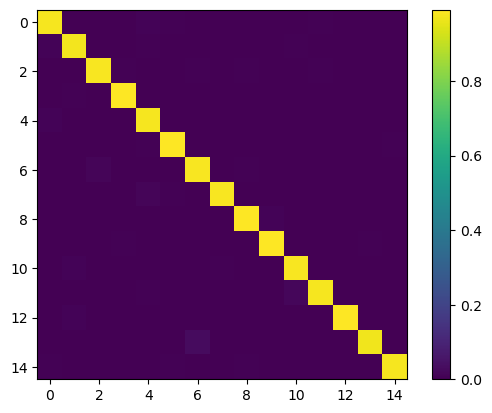

In [34]:
plt.imshow(model.transmat_, cmap="viridis")
plt.colorbar()

In [35]:


def compute_state_signatures(
    states,
    returns,
    volatility,
    price,
    lookback_weight=None
):
    """
    returns DataFrame of shape (K, features)
    """

    K = int(states.max()) + 1
    sig = []
    print("Computing signatures for", K, "states")

    T = len(states)
    weights = (
        np.exp(-np.arange(T)[::-1] / lookback_weight)
        if lookback_weight is not None
        else np.ones(T)
    )

    for k in range(K):
        print(f"State {k}: ", end="")
        idx = states == k
        if idx.sum() < 30:
            print("Ignoring ", idx)
            continue

        w = weights[idx]

        sig.append({
            "state": k,
            "freq": idx.mean(),
            "mean_return": np.average(returns[idx], weights=w),
            "volatility": np.average(volatility[idx], weights=w),
            "trend": np.polyfit(
                np.arange(idx.sum()),
                price[idx],
                1
            )[0],
            "drawdown": np.min(
                price[idx] / np.maximum.accumulate(price[idx]) - 1
            ),
        })

    return pd.DataFrame(sig).set_index("state")

In [36]:
# X_emb        # ts2vec embeddings (T, D)
# returns      # daily log returns (T,)
# volatility   # rolling vol (T,)
# price        # index price (T,)
# states       # HMM state sequence (T,)
# posteriors   # HMM posteriors (T, K)

returns = np.log(df["Close"] / df["Close"].shift(1)).fillna(0).values
volatility = df["Close"].rolling(20).std().bfill().values
price = df["Close"].values
states = viterbi
state_df = compute_state_signatures(
    states, returns, volatility, price, lookback_weight=100
)


Computing signatures for 15 states
State 0: State 1: State 2: State 3: State 4: State 5: State 6: State 7: State 8: State 9: State 10: State 11: State 12: State 13: State 14: 

In [37]:

state_df.sort_values("freq", ascending=False)

,freq,mean_return,volatility,trend,drawdown
state,,,,,
4,0.122170,0.001055,153.120707,11.604600,-0.170728
0,0.117925,0.001522,234.199852,8.574420,-0.228953
5,0.114151,0.002361,247.158290,7.670267,-0.453684
1,0.094104,-0.000146,166.318085,17.031829,-0.103957
10,0.084198,-0.010718,587.908343,11.153751,-0.376270
3,0.080896,0.001029,267.923582,29.485386,-0.100820
8,0.078538,-0.000284,252.050221,36.330803,-0.077634
2,0.047642,-0.000614,252.979026,27.774398,-0.069283
9,0.046462,0.001121,321.855585,40.683886,-0.108431


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

features = [
    "mean_return",
    "volatility",
    "trend",
    "drawdown",
]

X_state = StandardScaler().fit_transform(state_df[features])

clusterer = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

state_df["macro_regime"] = clusterer.fit_predict(X_state)

In [39]:
state_to_macro = state_df["macro_regime"].to_dict()
macro_states = np.array([state_to_macro[s] for s in states])

In [40]:
macro_summary = (
    state_df
    .groupby("macro_regime")
    .agg({
        "mean_return": "mean",
        "volatility": "mean",
        "trend": "mean",
        "drawdown": "mean",
    })
)

In [41]:
labels = {}

ret_rank = macro_summary["mean_return"].rank()
vol_rank = macro_summary["volatility"].rank()
dd_rank  = macro_summary["drawdown"].rank()

for k in macro_summary.index:
    if ret_rank[k] == ret_rank.max() and vol_rank[k] <= 3:
        labels[k] = "Strong Bull"

    elif ret_rank[k] >= 4:
        labels[k] = "Bull"

    elif ret_rank[k] <= 2 and dd_rank[k] <= 2:
        labels[k] = "Bear"

    elif vol_rank[k] == vol_rank.max():
        labels[k] = "High Volatility"

    else:
        labels[k] = "Sideways / Transition"

In [42]:
macro_summary["label"] = macro_summary.index.map(labels)

In [44]:
macro_summary

,mean_return,volatility,trend,drawdown,label
macro_regime,,,,,
0,0.000580,252.521029,41.255154,-0.108020,Sideways / Transition
1,0.003024,314.579916,10.140549,-0.358301,Strong Bull
2,0.000819,490.801210,135.484185,-0.112527,Bull
3,-0.010718,587.908343,11.153751,-0.376270,Bear
4,0.000569,174.221806,17.922572,-0.135636,Sideways / Transition


In [45]:
bull_strength = {}

for k, row in macro_summary.iterrows():
    if row["label"] == "Strong Bull":
        bull_strength[k] = 1.0
    elif row["label"] == "Bull":
        bull_strength[k] = 0.7
    elif row["label"] == "Sideways / Transition":
        bull_strength[k] = 0.4
    elif row["label"] == "High Volatility":
        bull_strength[k] = 0.2
    else:  # Bear
        bull_strength[k] = 0.0

In [46]:
state_to_macro

{0: 4,
 1: 4,
 2: 0,
 3: 0,
 4: 4,
 5: 1,
 6: 4,
 7: 1,
 8: 0,
 9: 0,
 10: 3,
 11: 4,
 12: 4,
 13: 2,
 14: 0}

In [47]:
state_bull_strength = {
    s: bull_strength[state_to_macro[s]]
    for s in state_to_macro
}
state_bull_strength

{0: 0.4,
 1: 0.4,
 2: 0.4,
 3: 0.4,
 4: 0.4,
 5: 1.0,
 6: 0.4,
 7: 1.0,
 8: 0.4,
 9: 0.4,
 10: 0.0,
 11: 0.4,
 12: 0.4,
 13: 0.7,
 14: 0.4}

In [50]:
def bull_confidence_from_posteriors(posteriors, state_bull_strength):
    """
    posteriors: (T, K)
    returns: (T,) bull confidence in [0, 1]
    """
    weights = np.array([
        state_bull_strength[k] for k in range(posteriors.shape[1])
    ])
    return posteriors @ weights

In [51]:
posteriors

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 1.00000000e+000],
       [2.86398931e-080, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 1.00000000e+000],
       [2.57558592e-084, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 1.00000000e+000],
       ...,
       [0.00000000e+000, 2.04054521e-134, 4.77317986e-254, ...,
        1.07855480e-219, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 1.53117924e-102, 6.52871160e-267, ...,
        5.04955221e-191, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 1.89239604e-071, 9.37813625e-273, ...,
        2.18374311e-136, 0.00000000e+000, 0.00000000e+000]])

In [55]:
bull_conf = bull_confidence_from_posteriors(
    posteriors,
    state_bull_strength
)
bull_conf

array([0.7, 0.7, 0.7, ..., 0.4, 0.4, 0.4])

In [56]:
# plot bull confidence over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf,
        mode="lines",
        name="Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [57]:
def smooth_series(x, half_life=20):
    alpha = 1 - np.exp(np.log(0.5) / half_life)
    y = np.zeros_like(x)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = alpha * x[t] + (1 - alpha) * y[t-1]
    return y

bull_conf_smooth = smooth_series(bull_conf, half_life=20)


In [60]:
# plot bull_conf_smooth over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_smooth,
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Smoothed Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Smoothed Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [58]:
bull_momentum = bull_conf_smooth - smooth_series(
    bull_conf_smooth, half_life=60
)

In [59]:
# plot bull momentum over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_momentum,
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Momentum",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()